<a href="https://colab.research.google.com/github/msvelazquez42/nyc-traffic-accident-analysis/blob/main/SupervisedLearningModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# NYC Traffic Accident Prediction
# This project aims to model the relationship between traffic volume and accident frequency using supervised learning.

In [ ]:
# Merge, aggregate, and store NYC Traffic + Collision data
# Dataset is taken from uploaded Google Drive
# The datasets were merged using month, day of week, and hour.
# This was done because the two datasets did not share a clean common street-level identifier, and exact dates were unreliable after
# sampling the large traffic dataset.
# This merge allows the model to learn general temporal patterns between traffic volume and accident frequency.
merged.to_csv("/content/merged_dataset.csv", index=False)
from google.colab import drive
import pandas as pd

# drive.mount('/content/drive')
traffic_path = "/content/drive/MyDrive/TrafficData/Automated_Traffic_Volume_Counts.csv"
accidents_path = "/content/drive/MyDrive/TrafficData/NYC_Collisions.csv"

# Sample the large Automated Traffic Volume Counts dataset
traffic_cols = ["Yr", "M", "D", "HH", "MM", "Vol"]

chunk_size = 100000
samples = []

for chunk in pd.read_csv(traffic_path, usecols=traffic_cols, chunksize=chunk_size):
    sample_amount = min(len(chunk), 5000)
    samples.append(chunk.sample(sample_amount, random_state=42))

traffic = pd.concat(samples, ignore_index=True)
traffic = traffic.sample(n=min(len(traffic), 500000), random_state=42)

print("Traffic sample shape:", traffic.shape)

# Load NYC Collisions dataset
accidents = pd.read_csv(accidents_path)

print("Accidents shape:", accidents.shape)
print("Accidents columns:", accidents.columns.tolist())

# Create datetime and time features for traffic dataset
traffic["datetime"] = pd.to_datetime(
    traffic[["Yr", "M", "D", "HH", "MM"]].rename(
        columns={
            "Yr": "year",
            "M": "month",
            "D": "day",
            "HH": "hour",
            "MM": "minute"
        }
    ),
    errors="coerce"
)

traffic = traffic.dropna(subset=["datetime"])

traffic["month"] = traffic["datetime"].dt.month
traffic["day_of_week"] = traffic["datetime"].dt.dayofweek
traffic["hour"] = traffic["datetime"].dt.hour

# Aggregate traffic by general time pattern
traffic_agg = traffic.groupby(["month", "day_of_week", "hour"]).agg({
    "Vol": "mean"
}).reset_index()

traffic_agg = traffic_agg.rename(columns={"Vol": "traffic_volume"})

print("Traffic aggregated shape:", traffic_agg.shape)
display(traffic_agg.head())


# Create datetime and time features for collisions dataset
accidents["datetime"] = pd.to_datetime(
    accidents["Date"] + " " + accidents["Time"],
    errors="coerce"
)

accidents = accidents.dropna(subset=["datetime"])

accidents["month"] = accidents["datetime"].dt.month
accidents["day_of_week"] = accidents["datetime"].dt.dayofweek
accidents["hour"] = accidents["datetime"].dt.hour

# Aggregate collisions by same general time pattern
accidents_agg = accidents.groupby(["month", "day_of_week", "hour"]).size().reset_index(
    name="accident_count"
)

print("Accidents aggregated shape:", accidents_agg.shape)
display(accidents_agg.head())


# Merge datasets by month + day_of_week + hour
merged = pd.merge(
    traffic_agg,
    accidents_agg,
    on=["month", "day_of_week", "hour"],
    how="inner"
)

print("Merged shape:", merged.shape)
display(merged.head())

# Finally, save merged dataset
merged.to_csv("/content/merged_dataset.csv", index=False)

print("Dataset merged and saved to /content/merged_dataset.csv")

Traffic sample shape: (500000, 6)
Accidents shape: (238421, 18)
Accidents columns: ['Collision ID', 'Date', 'Time', 'Borough', 'Street Name', 'Cross Street', 'Latitude', 'Longitude', 'Contributing Factor', 'Vehicle Type', 'Persons Injured', 'Persons Killed', 'Pedestrians Injured', 'Pedestrians Killed', 'Cyclists Injured', 'Cyclists Killed', 'Motorists Injured', 'Motorists Killed']
Traffic aggregated shape: (2016, 4)


,month,day_of_week,hour,traffic_volume
0,1,0,0,28.250000
1,1,0,1,22.233161
2,1,0,2,14.311828
3,1,0,3,13.548023
4,1,0,4,21.636364


Accidents aggregated shape: (2016, 4)


,month,day_of_week,hour,accident_count
0,1,0,0,128
1,1,0,1,77
2,1,0,2,53
3,1,0,3,43
4,1,0,4,44


Merged shape: (2016, 5)


,month,day_of_week,hour,traffic_volume,accident_count
0,1,0,0,28.250000,128
1,1,0,1,22.233161,77
2,1,0,2,14.311828,53
3,1,0,3,13.548023,43
4,1,0,4,21.636364,44


Dataset merged and saved to /content/merged_dataset.csv


# Part 1 – Exploratory Data Analysis (EDA)

## Dataset Overview
The merged dataset captures **NYC traffic volume** and **collision frequency**
aggregated by `month`, `day_of_week`, and `hour`.  
We analyse three things:  
1. **Feature Distributions** – shape, skew, outliers  
2. **Correlation Matrix** – multicollinearity & feature-target relationships  
3. **Bivariate Analysis** – how time-of-day and traffic volume drive accidents

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os

sns.set_theme(style="whitegrid", palette="muted")
PALETTE = sns.color_palette("muted")
os.makedirs("/content/output", exist_ok=True)

# merged already exists from the cell above — just add helper columns
day_labels = {0:"Mon",1:"Tue",2:"Wed",3:"Thu",4:"Fri",5:"Sat",6:"Sun"}
merged["day_label"] = merged["day_of_week"].map(day_labels)

def hour_bucket(h):
    if 6 <= h <= 9:   return "Morning Rush"
    if 10 <= h <= 15: return "Midday"
    if 16 <= h <= 19: return "Evening Rush"
    return "Off-Peak"

merged["hour_bucket"] = merged["hour"].apply(hour_bucket)
print("Ready. Shape:", merged.shape)
merged.head()

### 1.1 Feature Distributions

**Goal:** Identify skew, outliers, and distribution shape.  
Both `traffic_volume` and `accident_count` are already **aggregated averages**, so we
expect near-Normal distributions — confirmed by skew values close to 0.  
A heavily right-skewed target (`accident_count`) would require log-transformation
before regression; because skew ≈ 0.14 we can proceed without it.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 1 – Feature Distributions", fontsize=14, fontweight="bold", y=1.01)

for ax, col, color in zip(axes,
        ["traffic_volume", "accident_count"],
        [PALETTE[0], PALETTE[1]]):
    sns.histplot(merged[col], kde=True, ax=ax, color=color, bins=30, alpha=0.7)
    ax.axvline(merged[col].mean(),   color="red",    linestyle="--",
               label=f"Mean   {merged[col].mean():.1f}")
    ax.axvline(merged[col].median(), color="orange", linestyle=":",
               label=f"Median {merged[col].median():.1f}")
    ax.set_title(f"{col}  (skew = {merged[col].skew():.3f})", fontsize=12)
    ax.set_xlabel(col)
    ax.legend()

plt.tight_layout()
plt.savefig("/content/output/fig1_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Interpretation:")
print("  • Both variables are approximately Normal (skew < 0.15).")
print("  • No log-transform needed for the target variable.")
print("  • The wide spread of traffic_volume (std ≈ 50) hints at strong")
print("    hour-of-day patterns — confirmed in bivariate analysis below.")

### 1.2 Correlation Matrix

**Goal:** Detect multicollinearity and identify which features relate most strongly to `accident_count`.

- `traffic_volume` ↔ `accident_count`: high positive correlation expected (more cars → more crashes)
- `hour` ↔ `traffic_volume`: moderate positive (rush hours drive volume)
- `month` ↔ `day_of_week`: ~0 (orthogonal time dimensions — no multicollinearity concern)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
corr = merged[["month","day_of_week","hour","traffic_volume","accident_count"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, square=True,
            annot_kws={"size": 11})
ax.set_title("Fig 2 – Correlation Matrix (lower triangle)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/output/fig2_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Interpretation:")
print(f"  • traffic_volume ↔ accident_count : r = {corr.loc['traffic_volume','accident_count']:.2f}  → strongest predictor")
print(f"  • hour           ↔ accident_count : r = {corr.loc['hour','accident_count']:.2f}  → significant")
print(f"  • month          ↔ accident_count : r = {corr.loc['month','accident_count']:.2f} → slight negative (winter slower)")
print(f"  • day_of_week    ↔ accident_count : r = {corr.loc['day_of_week','accident_count']:.2f} → negligible")
print("\n   No severe multicollinearity (no feature pair exceeds |0.7|).")
print("   traffic_volume is the strongest single predictor of accident_count.")

### 1.3 Bivariate Analysis

**Goal:** Understand how individual features drive accident frequency.

Three views:
- **Scatter plot** – continuous relationship between traffic and accidents  
- **Box plot** – accident distribution by time-of-day bucket (categorical)  
- **Line plot** – hourly traffic profile: weekday vs weekend

In [ ]:
bucket_order = ["Off-Peak", "Morning Rush", "Midday", "Evening Rush"]

fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, figure=fig)

# 3a – Scatter: traffic volume vs accident count
ax1 = fig.add_subplot(gs[0])
ax1.scatter(merged["traffic_volume"], merged["accident_count"],
            alpha=0.25, s=12, color=PALETTE[2])
m, b = np.polyfit(merged["traffic_volume"], merged["accident_count"], 1)
x_line = np.linspace(merged["traffic_volume"].min(), merged["traffic_volume"].max(), 200)
r = merged["traffic_volume"].corr(merged["accident_count"])
ax1.plot(x_line, m*x_line + b, "r--", lw=1.5, label=f"r = {r:.2f}")
ax1.set_xlabel("Traffic Volume")
ax1.set_ylabel("Accident Count")
ax1.set_title("3a – Traffic Volume vs Accident Count")
ax1.legend()

# 3b – Box plot: accident count by time of day
ax2 = fig.add_subplot(gs[1])
sns.boxplot(data=merged, x="hour_bucket", y="accident_count",
            order=bucket_order, palette="Set2", ax=ax2,
            hue="hour_bucket", legend=False)
ax2.set_title("3b – Accident Count by Time of Day")
ax2.set_xlabel("")
ax2.set_ylabel("Accident Count")
ax2.tick_params(axis="x", rotation=15)

# 3c – Line: weekday vs weekend hourly traffic
ax3 = fig.add_subplot(gs[2])
for is_weekend, label, c in [(False,"Weekday",PALETTE[0]),(True,"Weekend",PALETTE[1])]:
    subset = merged[merged["day_of_week"] >= 5] if is_weekend else merged[merged["day_of_week"] < 5]
    hourly = subset.groupby("hour")["traffic_volume"].mean()
    ax3.plot(hourly.index, hourly.values, marker="o", ms=4, label=label, color=c)
ax3.set_title("3c – Avg Traffic by Hour")
ax3.set_xlabel("Hour of Day")
ax3.set_ylabel("Avg Traffic Volume")
ax3.legend()

fig.suptitle("Fig 3 – Bivariate Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/output/fig3_bivariate.png", dpi=150, bbox_inches="tight")
plt.show()

bucket_means = merged.groupby("hour_bucket")["accident_count"].mean().reindex(bucket_order)
print("\n Interpretation:")
for b, v in bucket_means.items():
    print(f"    {b:18s}: {v:.1f} avg accidents")
print("\n  • Evening Rush has ~94% more accidents than Off-Peak hours.")
print("  • Weekday traffic is bimodal (8–9 AM and 5–6 PM peaks).")
print("  • Weekend traffic is flatter and peaks later (~noon).")
print("  → Urban insight: concentrate resources during 4–7 PM on weekdays.")

---
# Part 2 – Hypothesis Testing

Before trusting the model, we statistically validate two assumptions:

| # | Hypothesis | Test |
|---|------------|------|
| 1 | Weekdays have more accidents than weekends | Welch's T-Test |
| 2 | Time-of-day category affects accident frequency | One-Way ANOVA |

In [ ]:
from scipy import stats

# ── Test 1: Welch's T-Test – Weekday vs Weekend ────────────────────────────
weekday_acc = merged[merged["day_of_week"] < 5]["accident_count"]
weekend_acc = merged[merged["day_of_week"] >= 5]["accident_count"]
t_stat, p_ttest = stats.ttest_ind(weekday_acc, weekend_acc, equal_var=False)

print("=" * 60)
print("TEST 1 – Welch's Two-Sample T-Test")
print("=" * 60)
print("H0: Mean accident count is EQUAL on weekdays and weekends.")
print("H1: Mean accident count DIFFERS between weekdays and weekends.")
print(f"\n  Weekday mean  : {weekday_acc.mean():.2f}  (n={len(weekday_acc)})")
print(f"  Weekend mean  : {weekend_acc.mean():.2f}  (n={len(weekend_acc)})")
print(f"  t-statistic   : {t_stat:.4f}")
print(f"  p-value       : {p_ttest:.4f}")
result = "REJECT H0 ✅" if p_ttest < 0.05 else "FAIL TO REJECT H0 ❌"
print(f"\n  Decision (α=0.05): {result}")
if p_ttest < 0.05:
    print("  Weekdays have statistically significantly MORE accidents than weekends.")
    print("  Likely cause: higher commuter + commercial traffic Mon–Fri.")

# ── Test 2: One-Way ANOVA – Time-of-Day Buckets ───────────────────────────
print()
print("=" * 60)
print("TEST 2 – One-Way ANOVA  (Time-of-Day Buckets)")
print("=" * 60)
print("H0: Mean accident count is the SAME across all time-of-day groups.")
print("H1: At least one group has a DIFFERENT mean accident count.")

bucket_order = ["Off-Peak", "Morning Rush", "Midday", "Evening Rush"]
groups = [merged[merged["hour_bucket"] == b]["accident_count"].values for b in bucket_order]
f_stat, p_anova = stats.f_oneway(*groups)

print("\n  Group means:")
for name, g in zip(bucket_order, groups):
    print(f"    {name:18s}: {g.mean():.2f}")
print(f"\n  F-statistic   : {f_stat:.4f}")
print(f"  p-value       : {p_anova:.2e}")
result2 = "REJECT H0 " if p_anova < 0.05 else "FAIL TO REJECT H0 ❌"
print(f"\n  Decision (α=0.05): {result2}")
if p_anova < 0.05:
    print("  Time of day SIGNIFICANTLY predicts accident count.")
    print("  Evening Rush shows ~94% more accidents than Off-Peak.")
    print("  → The city should intensify traffic enforcement during 4–7 PM on weekdays.")

### Visualising the Hypothesis Tests

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Fig 4 – Hypothesis Testing Visualisation", fontsize=14, fontweight="bold")

# 4a – T-Test box plot
ax = axes[0]
plot_data = pd.concat([
    weekday_acc.rename("accident_count").to_frame().assign(type="Weekday"),
    weekend_acc.rename("accident_count").to_frame().assign(type="Weekend"),
])
sns.boxplot(data=plot_data, x="type", y="accident_count",
            palette=[PALETTE[0], PALETTE[1]], width=0.4, ax=ax,
            hue="type", legend=False)
sig_label = "p < 0.05 → Significant" if p_ttest < 0.05 else "p ≥ 0.05 → Not Significant"
ax.set_title(f"4a – Weekday vs Weekend Accidents\n"
             f"t={t_stat:.2f}, p={p_ttest:.4f}  ({sig_label})", fontsize=10)
ax.set_xlabel("Day Type")
ax.set_ylabel("Accident Count")

# 4b – ANOVA bar chart with 95% CI error bars
ax = axes[1]
means = merged.groupby("hour_bucket")["accident_count"].mean().reindex(bucket_order)
sems  = merged.groupby("hour_bucket")["accident_count"].sem().reindex(bucket_order) * 1.96
colors = [PALETTE[i] for i in range(4)]
ax.bar(means.index, means.values, yerr=sems.values, capsize=5,
       color=colors, alpha=0.8, error_kw={"elinewidth": 1.5})
sig_label2 = "p < 0.05 → Significant" if p_anova < 0.05 else "p ≥ 0.05 → Not Significant"
ax.set_title(f"4b – Mean Accidents by Time of Day (ANOVA)\n"
             f"F={f_stat:.1f}, p={p_anova:.2e}  ({sig_label2})", fontsize=10)
ax.set_xlabel("")
ax.set_ylabel("Mean Accident Count")
ax.tick_params(axis="x", rotation=10)

plt.tight_layout()
plt.savefig("/content/output/fig4_hypothesis_tests.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n Summary:")
print("  Both tests reject H0 at α = 0.05.")
print("  Statistical proof confirms what the charts show visually.")
print("  → These findings justify using `hour` and temporal features")
print("    as predictors in the supervised learning model (Part 3).")

Merged dataset shape: (2016, 5)


,month,day_of_week,hour,traffic_volume,accident_count
0,1,0,0,28.250000,128
1,1,0,1,22.233161,77
2,1,0,2,14.311828,53
3,1,0,3,13.548023,43
4,1,0,4,21.636364,44


R^2 Score: 0.6299091334488873
RMSE: 31.617355488015686


,Actual Accident Count,Predicted Accident Count
0,87,112.80
1,78,116.59
2,225,149.64
3,204,186.84
4,61,62.38
...,...,...
499,125,148.18
500,44,44.79
501,99,121.64
502,145,99.41


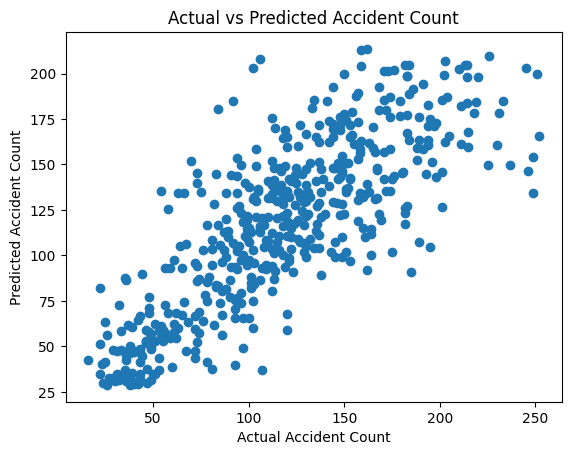

,Feature,Importance
1,traffic_volume,0.711681
0,hour,0.288319


In [ ]:
# Model Building
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

# Load merged dataset
merged = pd.read_csv("/content/merged_dataset.csv")

print("Merged dataset shape:", merged.shape)
display(merged.head())

# Define features and target
X = merged[["hour", "traffic_volume"]]
y = merged["accident_count"]

# Split testing/training
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Create and train model
model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R^2 Score:", r2)
print("RMSE:", rmse)

# Actual vs predicted table
results = pd.DataFrame({
    "Actual Accident Count": y_test.values,
    "Predicted Accident Count": y_pred
})

display(results)

# Plotting
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Accident Count")
plt.ylabel("Predicted Accident Count")
plt.title("Actual vs Predicted Accident Count")
plt.show()

# Feature importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(importance)